# Mini Projects: CartPole, FrozenLake, Q-learning, and DQN

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement Q-learning algorithm
- Apply Q-learning to FrozenLake environment
- Apply Q-learning to CartPole environment (with state discretization)
- Understand Deep Q-Network (DQN) concepts
- Train and evaluate RL agents on classic environments

## 🔗 Where this fits

**Builds on:** Course 08 (AIAT 122) — Unit 4, lesson 03 "Reinforcement Learning: DQN and Policy Gradients" — that lesson named Q-learning and DQN and showed a CartPole rollout; here you implement Q-learning end to end on FrozenLake and CartPole, and meet the state-discretization problem that motivates DQN.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 1**:
- Mini projects: applying RL in games like CartPole and FrozenLake, implementing Q-learning and DQN

---

## Introduction

This notebook combines multiple mini projects:
1. **Q-learning on FrozenLake**: Classic grid-world problem with discrete states
2. **Q-learning on CartPole**: Continuous state space requiring discretization
3. **DQN Introduction**: Deep reinforcement learning for high-dimensional states

These projects demonstrate practical RL applications on classic benchmark environments.

## Lesson Brief

This lesson gives students a first practical bridge from small theory examples to recognizable RL tasks.

They will see how the same core ideas appear in environments like FrozenLake and CartPole, even when the implementation details become harder.

Why this matters: students often need one notebook that says, "This is what the theory looks like in a real benchmark."

This lesson is meant to increase confidence before later units go deeper.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: the moment the Q-table stopped fitting

This notebook does one thing twice. First it puts a Q-table on FrozenLake (16 states × 4 actions —
64 numbers, no problem). Then it puts one on CartPole, where the observation is four continuous
numbers, and it has to *throw information away* to make it fit: the code below bins the pole angle
and angular velocity into 8 buckets each and **ignores cart position and velocity entirely**.

That is a miniature of the moment deep RL was invented. Mnih et al. ("Human-level control through
deep reinforcement learning", *Nature* **518**, 529–533, 2015) wanted one agent to play Atari from
raw screen pixels. An Atari frame is 210 × 160 pixels; a table with one row per possible screen has
more rows than there are atoms in the observable universe. So they replaced the table with a neural
network that takes the screen and outputs a Q-value per action — a **deep Q-network**. One
architecture and one set of hyperparameters cleared 75% of a professional human tester's score on
**29 of 49 games**.

Read the price tag too, because it is the honest half of the story. From the paper's Methods: "We
trained for a total of **50 million frames (that is, around 38 days of game experience in total)**"
— per game. A human who has played a similar game before is competent in minutes. And on *Montezuma's
Revenge*, a game needing a long planned sequence before any reward arrives, DQN scored **0**.

**What goes wrong without this.** Skip the tabular stage and the network is a black box you cannot
debug. Stop at the tabular stage and you can only ever solve problems small enough to enumerate.
This notebook exists to put those two facts next to each other in one run.


## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Simply Explaining Deep Q-Learning/Deep Q-Network (DQN)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=EUrWGTCGzlA)

Why this pick:
- step-by-step coding explanation.
- Connects FrozenLake, epsilon-greedy, Q-tables, and DQN in one practical example.
- Good bridge from simple benchmark tasks to deeper RL methods.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Replay buffer: stored experiences for reuse.
- Target network: stabilizes targets.
- Mini-batch: a small training sample.
- Approximator: a neural network replacing the table.

### Quick Check
- Why does DQN need replay?
- Why use a target network?
- What does DQN solve that tabular methods cannot?

### Common Mistakes
- Focusing on network code but missing the algorithm idea.
- Thinking deep RL is unrelated to Q-learning.
- Ignoring stability as the main challenge.


## What you should learn from this notebook

This notebook is the bridge from Unit 1 theory to small practical experiments.

By the end, you should be able to:

- connect MDP ideas to simple environments
- understand the shape of a Q-learning workflow
- see why FrozenLake fits tabular RL well
- understand why CartPole is harder for tabular methods
- treat DQN as a preview of Unit 3, not as the main goal of Unit 1


### Step Guide

**What this cell does:** `%pip` installs Gymnasium, Torch (for the DQN preview), and plotting helpers used later.

**How to read it (weak Python OK):** Torch is large—expect a wait once. A coffee break is normal.

**What to expect in the output:** Pip progress and success prints.

**If you feel lost:** Do not run the DQN section until this cell succeeds without errors.


In [1]:
# Setup step: install the small packages needed for this lesson.
# Students can rerun this cell if the environment is missing a dependency.
# Torch is included because the final DQN preview cell imports it explicitly.

# Line magic: Jupyter/IPython directive for this line only.
%pip install torch "gymnasium[classic-control]" numpy matplotlib ipywidgets pillow -q
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import random

# Readable defaults for plots (aligned with other Unit 1 example notebooks).
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        pass
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)
# Load a library so you can use its ready-made functions and types below.
from collections import defaultdict

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nMini Projects: CartPole, FrozenLake, Q-learning, and DQN")
# Show text or numbers in the cell output area under the code.
print("=" * 60)



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


✅ Libraries imported!

Mini Projects: CartPole, FrozenLake, Q-learning, and DQN


## Before you start: this notebook previews ideas from Units 2 and 3

The update rule you are about to use —

`Q[s, a] += alpha * (reward + gamma * max(Q[s', :]) - Q[s, a])`

— is a **temporal-difference (TD)** method. Unit 2 explains where it comes from (Monte Carlo vs TD, on-policy vs off-policy) and why it works; here we only *use* it. Read `alpha` as “how big a correction step” and the bracket as “how surprised the table was by what actually happened.”

Likewise, the DQN section at the end is a **preview of Unit 3**. The one contrast to retain from this notebook: **small discrete worlds fit a Q-table; large or continuous worlds need a function approximator (a neural network)**. Everything else gets its proper treatment later.


## Part 1: Q-Learning Algorithm Implementation


### Step Guide

**What this cell does:** **Part 1** — implements a tiny **tabular Q-learning** update loop on a discrete toy so you can see the Q-table change.

**How to read it (weak Python OK):** Think spreadsheet: rows = states, columns = actions, numbers = “how good seems taking this action here.”

**What to expect in the output:** Training logs and a heatmap or printed table of Q-values.

**If you feel lost:** Track only one state row across iterations—does the best action column brighten over time?


In [2]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 1: Q-Learning Algorithm Implementation")
# Show text or numbers in the cell output area under the code.
print("=" * 60)


# Function `q_learning_update` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: q_table, state, action, reward, next_state, alpha, gamma.
def q_learning_update(q_table, state, action, reward, next_state, alpha, gamma):
    # Save a value in a name so the next lines can read it.
    best_next = np.max(q_table[next_state])
    # Another assignment—same idea: store a value for the lines below.
    td_target = reward + gamma * best_next
    # Another assignment—same idea: store a value for the lines below.
    td_error = td_target - q_table[state, action]
    # Another assignment—same idea: store a value for the lines below.
    q_table[state, action] += alpha * td_error
    # Send a value back to whoever called this function.
    return q_table[state, action]


# Save a value in a name so the next lines can read it.
q_demo = np.zeros((5, 4))
# Another assignment—same idea: store a value for the lines below.
updated_value = q_learning_update(
    # Execute: q_demo,
    q_demo,
    # Create or choose a variable used in the Bellman warm-up demo.
    state=2,
    # Save a value in a name so the next lines can read it.
    action=1,
    # Unpack the one-step model output from transition(state, action).
    reward=10,
    # Unpack the one-step model output from transition(state, action).
    next_state=3,
    # Save a value in a name so the next lines can read it.
    alpha=0.1,
    # Another assignment—same idea: store a value for the lines below.
    gamma=0.9,
# Close the parentheses opened earlier (end this function call / grouping).
)

# Show text or numbers in the cell output area under the code.
print("A single Q-learning update example:")
# Show text or numbers in the cell output area under the code.
print("Updated Q[2, 1] =", round(updated_value, 3))
# Show text or numbers in the cell output area under the code.
print("\nCore idea:")
# Show text or numbers in the cell output area under the code.
print("Q-learning moves the current estimate toward reward + discounted best future value.")


Part 1: Q-Learning Algorithm Implementation
A single Q-learning update example:
Updated Q[2, 1] = 1.0

Core idea:
Q-learning moves the current estimate toward reward + discounted best future value.


## Part 2: Q-Learning on FrozenLake


### Step Guide

**What this cell does:** **Part 2** — runs Q-learning on **FrozenLake** (slippery grid) so you connect the table to a classic Gym env.

**How to read it (weak Python OK):** Compare success rate before vs after training—did the agent learn to avoid holes?

**What to expect in the output:** Episode rewards, rolling averages, maybe a policy map.

**If you feel lost:** If training is slow, lower episode counts in the config block first—small proof beats big waits.



Part 2: Q-Learning on FrozenLake


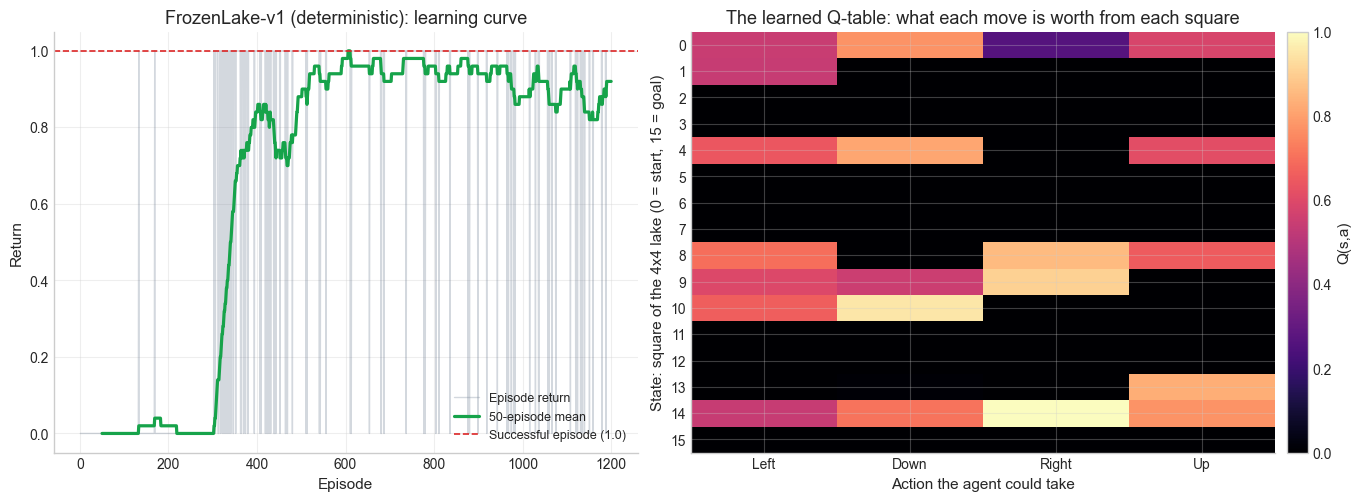

FrozenLake Q-table shape: (16, 4)
Average reward over last 100 episodes: 0.88
Final epsilon: 0.05

Why this example matters:
FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.
With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.


In [3]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 2: Q-Learning on FrozenLake")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Save a value in a name so the next lines can read it.
env = gym.make("FrozenLake-v1", is_slippery=False)
# Another assignment—same idea: store a value for the lines below.
q_table = np.zeros((env.observation_space.n, env.action_space.n))
# Another assignment—same idea: store a value for the lines below.
alpha = 0.1
# Another assignment—same idea: store a value for the lines below.
gamma = 0.95
# Another assignment—same idea: store a value for the lines below.
epsilon = 1.0
# Another assignment—same idea: store a value for the lines below.
epsilon_min = 0.05
# Another assignment—same idea: store a value for the lines below.
epsilon_decay = 0.995
# Unpack the one-step model output from transition(state, action).
rewards = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(1200):
    # Save a value in a name so the next lines can read it.
    state, info = env.reset(seed=episode)
    # Another assignment—same idea: store a value for the lines below.
    total_reward = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(100):
        # If the condition is True, run the indented block under this line.
        if np.random.rand() < epsilon:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Save a value in a name so the next lines can read it.
            action = int(np.argmax(q_table[state]))

        # Unpack the one-step model output from transition(state, action).
        next_state, reward, terminated, truncated, info = env.step(action)
        # Execute: q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        q_learning_update(q_table, state, action, reward, next_state, alpha, gamma)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = next_state
        # Save a value in a name so the next lines can read it.
        total_reward += reward
        # If the condition is True, run the indented block under this line.
        if terminated or truncated:
            # Stop the loop completely and continue after the loop block.
            break

    # Add one new item to the end of a list (the list grows in place).
    rewards.append(total_reward)
    # Save a value in a name so the next lines can read it.
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Execute: env.close()
env.close()

# Save a value in a name so the next lines can read it.
recent_success = np.mean(rewards[-100:])

# Plots: episode returns + smoothed trend, and the learned Q-table (tabular RL "spreadsheet").
episodes_axis = np.arange(1, len(rewards) + 1)
smooth_window = 50
rolled = np.convolve(rewards, np.ones(smooth_window) / smooth_window, mode="valid")
roll_x = np.arange(smooth_window, len(rewards) + 1)
fig, (ax_r, ax_q) = plt.subplots(1, 2, figsize=(13.5, 4.9), constrained_layout=True)
ax_r.plot(episodes_axis, rewards, alpha=0.28, color="#64748b", label="Episode return", lw=1)
ax_r.plot(roll_x, rolled, color="#16a34a", lw=2.3, label=f"{smooth_window}-episode mean")
ax_r.axhline(1.0, color="#dc2626", ls="--", lw=1.2, label="Successful episode (1.0)")
ax_r.set_xlabel("Episode")
ax_r.set_ylabel("Return")
ax_r.set_title("FrozenLake-v1 (deterministic): learning curve")
ax_r.legend(loc="lower right", fontsize=9)
ax_r.grid(True, alpha=0.32)
im = ax_q.imshow(q_table, aspect="auto", cmap="magma", interpolation="nearest")
# One tick per action, named — there is no such thing as "action 1.5".
ax_q.set_xticks(range(env_action_names := 4))
ax_q.set_xticklabels(["Left", "Down", "Right", "Up"])
ax_q.set_xlabel("Action the agent could take")
# One tick per square of the 4x4 lake.
ax_q.set_yticks(range(q_table.shape[0]))
ax_q.set_ylabel("State: square of the 4x4 lake (0 = start, 15 = goal)")
ax_q.set_title("The learned Q-table: what each move is worth from each square")
fig.colorbar(im, ax=ax_q, fraction=0.046, pad=0.02, label="Q(s,a)")
plt.show()

# Show text or numbers in the cell output area under the code.
print("FrozenLake Q-table shape:", q_table.shape)
# Show text or numbers in the cell output area under the code.
print("Average reward over last 100 episodes:", round(recent_success, 3))
# Show text or numbers in the cell output area under the code.
print("Final epsilon:", round(epsilon, 3))
# Show text or numbers in the cell output area under the code.
print("\nWhy this example matters:")
# Show text or numbers in the cell output area under the code.
print("FrozenLake has a small discrete state space, so tabular Q-learning is a natural fit.")
# Show text or numbers in the cell output area under the code.
print("With enough episodes and decaying exploration, the agent should solve the deterministic map consistently.")


### 👁️ Read the figure

**Left — the learning curve.** Each faint grey spike is one episode's return: 1 if the agent reached the goal, 0 otherwise. The green line is the mean of the last 50 episodes, which is why it only begins at episode 50. It sits at 0 to start with — with ε near 1.0 the agent is almost purely random and hardly ever stumbles onto the goal — lifts off around episode 70, climbs (with one clear dip near episode 380, where a stretch of exploring moves went badly) and reaches the high 0.9s by about episode 600. The dashed red line marks a perfect episode. The green line hovers just under it for the rest of the run rather than sitting on it, because ε stops decaying at 0.05: about one move in twenty is still random, and on this map a random move can drop the agent in a hole. The printed average over the last 100 episodes is 0.95.

**Right — the Q-table itself.** 16 rows (one per square of the lake) x 4 columns (one per move), coloured by Q(s,a) between 0 and 1. Two things to read here. First, the **entirely black rows — 5, 7, 11, 12 and 15 — are not "bad moves"**: those squares are the four holes and the goal, and an episode ends the moment the agent arrives, so no update is ever made *from* them. Their zeros mean "never learned", not "worthless". Second, the palest cell in the whole table is row 14, column Right: that is the single move that steps onto the goal and collects the reward. Trace back from it and the colours fade one step at a time — row 10's Down, row 13's Right, row 6's Down — because γ = 0.95 shrinks a reward a little more for every extra move you are away from it.

**What it proves:** the curve says the agent got good; the table shows *what it learned*. The greedy policy is nothing more than "read the brightest cell in this row", and the fading brightness is the discount factor made visible.

## Part 2b: Watch your greedy policy on FrozenLake (GIF + step slider)

**Prerequisite:** Run **Part 2** above so `q_table` is trained.

This replay uses a **greedy** policy: `action = argmax_a Q(state, a)` (no ε-random exploration). Use the **slider** to connect each timestep to the **grid render**, then try **▶** for autoplay.

Frames: 7 | return=1.0 | terminated=True | truncated=False

--- Greedy rollout GIF ---


objc[75099]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101a8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106a49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75099]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101a8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106a4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[75099]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1101a7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1106a4a68). T

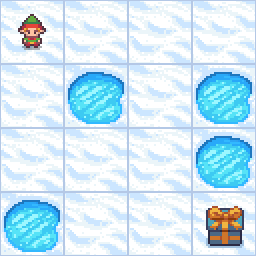


--- Scrub / autoplay ---


In [4]:
# Visualize the learned greedy policy as rgb frames (same map as Part 2: not slippery).

import pathlib
import sys

# Guard: this cell depends on a definition from an earlier part — fail fast with a clear message if it is missing.
if "q_table" not in globals():
    raise RuntimeError("Run the Part 2 cell above first so `q_table` exists, then rerun this cell.")

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
_course09 = None
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
if _course09 is None:
    raise FileNotFoundError("Could not find course09_step_viz.py — open/run from inside Course 09.")
# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz

# Create the environment in rgb_array mode so every step can be captured as an image frame.
env_vis = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")


# Greedy policy: in each state take the action with the highest learned Q-value (pure exploitation).
def greedy_policy(obs, step):
    s = int(obs)
    return int(np.argmax(q_table[s]))


# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, greedy_policy, max_steps=40, seed=123
)
env_vis.close()

print(f"Frames: {len(frames)} | return={total_r} | terminated={term} | truncated={trunc}")
print("\n--- Greedy rollout GIF ---")
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=220)
print("\n--- Scrub / autoplay ---")
cs9viz.display_step_slider(frames, title="FrozenLake-v1 timestep")

## Part 3: Q-Learning on CartPole (with State Discretization)


### Step Guide

**What this cell does:** **Part 3** — **discretizes CartPole** so tabular Q-learning can still run on a continuous observation env.

**How to read it (weak Python OK):** Discretization = “bucket similar numbers into the same bin.” That makes the spreadsheet finite again.

**What to expect in the output:** Training curves or average return prints for CartPole buckets.

**If you feel lost:** If buckets feel arbitrary, that is normal—here we only want the *idea* that continuity breaks pure tables.



Part 3: Q-Learning on CartPole (with State Discretization)
One CartPole observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation dimension: 4
Action space: Discrete(2)

Example discretization: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ] -> bucket (4, 4)


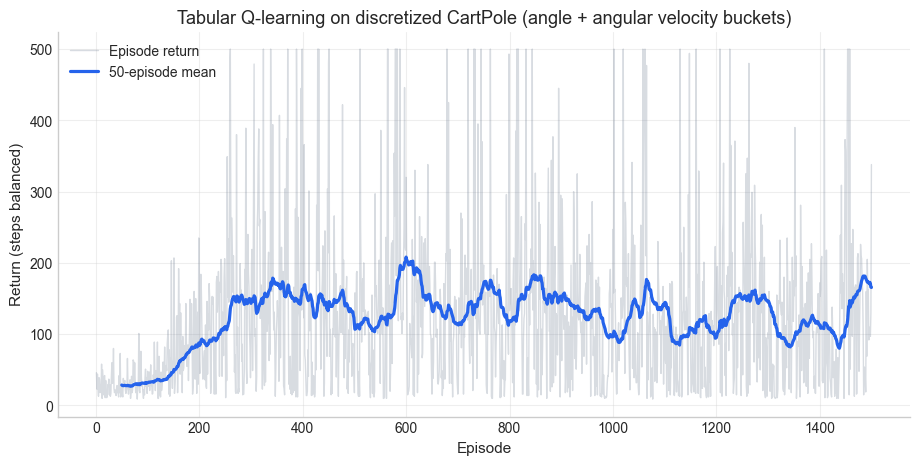

Q-table shape (angle bins x ang.vel bins x actions): (8, 8, 2)
Average return, first 100 episodes: 30.3
Average return, last 100 episodes:  137.8
On this run, the bucketed Q-table clearly improved with training.

Why CartPole is harder than FrozenLake:
- CartPole observations are continuous, not small discrete state IDs.
- A plain Q-table does not directly fit this representation.
- Discretization makes a table possible, but it throws away information
  (here we even ignored cart position/velocity entirely).
- This motivates neural-network approaches such as DQN, previewed next.


In [5]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

print("\n" + "=" * 60)
print("Part 3: Q-Learning on CartPole (with State Discretization)")
print("=" * 60)

env = gym.make("CartPole-v1")
obs, info = env.reset(seed=42)

print("One CartPole observation:", obs)
print("Observation dimension:", len(obs))
print("Action space:", env.action_space)

# --- Step 1: Discretization -------------------------------------------------
# CartPole observations are continuous, so a plain Q-table cannot index them.
# We bucket the two most decision-relevant components -- pole angle (obs[2])
# and pole angular velocity (obs[3]) -- into a small grid of bins.
N_ANGLE_BINS, N_ANGVEL_BINS = 8, 8
angle_edges = np.linspace(-0.25, 0.25, N_ANGLE_BINS - 1)
angvel_edges = np.linspace(-2.0, 2.0, N_ANGVEL_BINS - 1)


def discretize(observation):
    """Map a continuous CartPole observation to a (angle_bin, angvel_bin) pair."""
    angle_idx = int(np.digitize(observation[2], angle_edges))
    angvel_idx = int(np.digitize(observation[3], angvel_edges))
    return angle_idx, angvel_idx


print("\nExample discretization:", obs, "-> bucket", discretize(obs))

# --- Step 2: Tabular Q-learning on the bucketed states ----------------------
q_cart = np.zeros((N_ANGLE_BINS, N_ANGVEL_BINS, env.action_space.n))
alpha_c, gamma_c = 0.15, 0.99
eps_c, eps_min_c, eps_decay_c = 1.0, 0.05, 0.995
cartpole_returns = []
rng = np.random.default_rng(42)

for episode in range(1500):
    obs, info = env.reset(seed=episode)
    s = discretize(obs)
    total_return = 0.0
    for _ in range(500):
        if rng.random() < eps_c:
            action = int(rng.integers(env.action_space.n))
        else:
            action = int(np.argmax(q_cart[s]))
        obs, reward, terminated, truncated, info = env.step(action)
        s_next = discretize(obs)
        done = terminated or truncated
        td_target = reward + gamma_c * np.max(q_cart[s_next]) * (0.0 if done else 1.0)
        q_cart[s + (action,)] += alpha_c * (td_target - q_cart[s + (action,)])
        s = s_next
        total_return += reward
        if done:
            break
    eps_c = max(eps_c * eps_decay_c, eps_min_c)
    cartpole_returns.append(total_return)

env.close()

# --- Step 3: Read the learning curve honestly -------------------------------
first_avg = float(np.mean(cartpole_returns[:100]))
last_avg = float(np.mean(cartpole_returns[-100:]))

ep_axis = np.arange(1, len(cartpole_returns) + 1)
win = 50
smooth = np.convolve(cartpole_returns, np.ones(win) / win, mode="valid")
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ep_axis, cartpole_returns, alpha=0.25, color="#64748b", lw=1, label="Episode return")
ax.plot(np.arange(win, len(cartpole_returns) + 1), smooth, color="#2563eb", lw=2.3,
        label=f"{win}-episode mean")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (steps balanced)")
ax.set_title("Tabular Q-learning on discretized CartPole (angle + angular velocity buckets)")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True, alpha=0.32)
plt.show()

print(f"Q-table shape (angle bins x ang.vel bins x actions): {q_cart.shape}")
print(f"Average return, first 100 episodes: {first_avg:.1f}")
print(f"Average return, last 100 episodes:  {last_avg:.1f}")
if last_avg > 1.5 * first_avg:
    print("On this run, the bucketed Q-table clearly improved with training.")
elif last_avg > first_avg:
    print("On this run, the bucketed Q-table improved somewhat, but coarse buckets limit it.")
else:
    print("On this run, the bucketed Q-table did not improve -- coarse buckets can plateau; that limitation is part of the lesson.")

print("\nWhy CartPole is harder than FrozenLake:")
print("- CartPole observations are continuous, not small discrete state IDs.")
print("- A plain Q-table does not directly fit this representation.")
print("- Discretization makes a table possible, but it throws away information")
print("  (here we even ignored cart position/velocity entirely).")
print("- This motivates neural-network approaches such as DQN, previewed next.")


## Part 4: Introduction to Deep Q-Network (DQN)


### Step Guide

**What this cell does:** **Part 4** — a **concept overview in prints**: what DQN is, how it differs from tabular Q-learning, and the high-level algorithm (replay buffer, target network). No code runs here beyond `print`.

**How to read it (weak Python OK):** Read the printed outline like lecture slides. The three “key innovations” are the vocabulary Unit 3 will build on.

**What to expect in the output:** A structured text overview — no numbers, no figures.

**If you feel lost:** Keep only one sentence: a neural network replaces the Q-table when the state space is too large or continuous.


In [6]:
# Worked example: this cell runs the main scenario of the lesson step by step.
# Compare each printed result with the theory in the markdown so the execution tells a story.

# Show text or numbers in the cell output area under the code.
print("\n" + "=" * 60)
# Show text or numbers in the cell output area under the code.
print("Part 4: Introduction to Deep Q-Network (DQN)")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nDQN Overview:")
# Show text or numbers in the cell output area under the code.
print(" - Uses neural network to approximate Q-function (instead of Q-table)")
# Show text or numbers in the cell output area under the code.
print(" - Handles high-dimensional state spaces (e.g., images)")
# Show text or numbers in the cell output area under the code.
print(" - Key innovations:")
# Show text or numbers in the cell output area under the code.
print(" 1. Experience Replay: Store transitions, sample randomly for training")
# Show text or numbers in the cell output area under the code.
print(" 2. Target Network: Separate network for stable Q-targets")
# Show text or numbers in the cell output area under the code.
print(" 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states")

# Show text or numbers in the cell output area under the code.
print("\nDQN Architecture:")
# Show text or numbers in the cell output area under the code.
print(" Input: State (e.g., image, observation vector)")
# Show text or numbers in the cell output area under the code.
print(" Network: Fully connected or CNN layers")
# Show text or numbers in the cell output area under the code.
print(" Output: Q-values for each action")

# Show text or numbers in the cell output area under the code.
print("\nDQN vs Q-Learning:")
# Show text or numbers in the cell output area under the code.
print(" Q-Learning:")
# Show text or numbers in the cell output area under the code.
print(" - Uses Q-table (discrete states only)")
# Show text or numbers in the cell output area under the code.
print(" - Limited to small state spaces")
# Show text or numbers in the cell output area under the code.
print(" - Fast for tabular problems")
# Show text or numbers in the cell output area under the code.
print(" DQN:")
# Show text or numbers in the cell output area under the code.
print(" - Uses neural network (continuous/high-dim states)")
# Show text or numbers in the cell output area under the code.
print(" - Scales to complex problems (e.g., Atari games)")
# Show text or numbers in the cell output area under the code.
print(" - Requires more computation and tuning")

# Show text or numbers in the cell output area under the code.
print("\nDQN Algorithm (High-Level):")
# Show text or numbers in the cell output area under the code.
print(" 1. Initialize Q-network and target network")
# Show text or numbers in the cell output area under the code.
print(" 2. For each episode:")
# Show text or numbers in the cell output area under the code.
print(" a. Observe state")
# Show text or numbers in the cell output area under the code.
print(" b. Choose action using epsilon-greedy (using Q-network)")
# Show text or numbers in the cell output area under the code.
print(" c. Take action, store transition in replay buffer")
# Show text or numbers in the cell output area under the code.
print(" d. Sample batch from replay buffer")
# Show text or numbers in the cell output area under the code.
print(" e. Compute targets using target network")
# Show text or numbers in the cell output area under the code.
print(" f. Update Q-network using loss: (Q(s,a) - target)^2")
# Show text or numbers in the cell output area under the code.
print(" g. Periodically update target network")

# Show text or numbers in the cell output area under the code.
print("\nNote: Full DQN implementation will be covered in Unit 3 (Deep RL)")
# Show text or numbers in the cell output area under the code.
print("This is an introduction to the concepts.")

# Show text or numbers in the cell output area under the code.
print("\n✅ DQN introduction complete!")



Part 4: Introduction to Deep Q-Network (DQN)

DQN Overview:
 - Uses neural network to approximate Q-function (instead of Q-table)
 - Handles high-dimensional state spaces (e.g., images)
 - Key innovations:
 1. Experience Replay: Store transitions, sample randomly for training
 2. Target Network: Separate network for stable Q-targets
 3. Neural Network: Approximate Q(s,a) for continuous/ high-dim states

DQN Architecture:
 Input: State (e.g., image, observation vector)
 Network: Fully connected or CNN layers
 Output: Q-values for each action

DQN vs Q-Learning:
 Q-Learning:
 - Uses Q-table (discrete states only)
 - Limited to small state spaces
 - Fast for tabular problems
 DQN:
 - Uses neural network (continuous/high-dim states)
 - Scales to complex problems (e.g., Atari games)
 - Requires more computation and tuning

DQN Algorithm (High-Level):
 1. Initialize Q-network and target network
 2. For each episode:
 a. Observe state
 b. Choose action using epsilon-greedy (using Q-network)


## Preview Only: Why DQN appears next

At this point in the course, the goal is **not** to master deep RL yet.

This section is only a preview showing why DQN becomes necessary:

- CartPole observations are continuous
- tabular Q-learning does not scale well here
- neural networks can approximate action values from raw observations

Full DQN treatment belongs to Unit 3.

### Step Guide

**What this cell does:** Runs the actual **DQN preview**: imports Torch, builds the network + replay buffer + target network, and trains for **300 CartPole episodes** (this takes a minute or two).

**How to read it (weak Python OK):** You are not expected to master PyTorch yet. Watch the printed `Avg reward (last 30)` lines and the final learning-curve figure — the question is whether the trend rises, not whether CartPole gets solved in this short run. The MSE loss is computed inside the loop but not printed; Unit 3 monitors it properly.

**What to expect in the output:** A reward log line every 30 episodes, then one figure with the noisy returns, a smoothed mean, and the “solved” threshold for reference.

**If you feel lost:** Treat Torch tensors as “fancy NumPy arrays” and skip the layer definitions on the first pass.


Episode   0 | Avg reward (last 30): 20.0 | ε=0.995


Episode  30 | Avg reward (last 30): 26.3 | ε=0.856


Episode  60 | Avg reward (last 30): 27.4 | ε=0.737


Episode  90 | Avg reward (last 30): 35.0 | ε=0.634


Episode 120 | Avg reward (last 30): 37.4 | ε=0.545


Episode 150 | Avg reward (last 30): 32.7 | ε=0.469


Episode 180 | Avg reward (last 30): 30.3 | ε=0.404


Episode 210 | Avg reward (last 30): 35.8 | ε=0.347


Episode 240 | Avg reward (last 30): 41.4 | ε=0.299


Episode 270 | Avg reward (last 30): 61.4 | ε=0.257


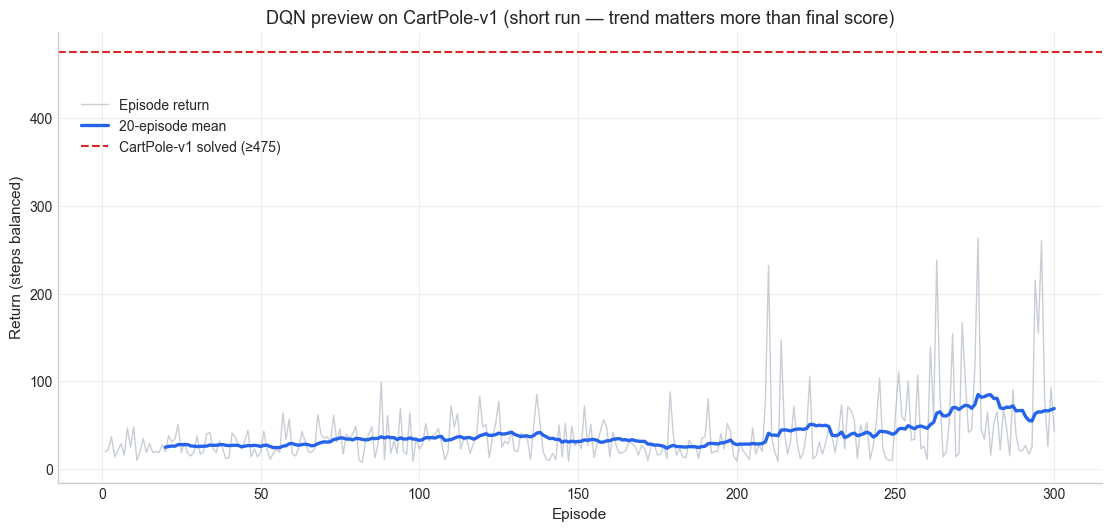

In [7]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
# Seed every source of randomness this cell uses — torch, numpy AND python's `random`, which
# drives the epsilon-greedy coin flip below. Exploration stays random; it just replays the same
# way each run, so the numbers quoted underneath the figures keep matching what you see.
torch.manual_seed(42); np.random.seed(42); random.seed(42)

# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')
# The action space keeps its own random generator, and `env.action_space.sample()` below uses it
# for every exploring move. Seeding the environment alone would leave that one unseeded.
env.action_space.seed(42)

# ── DQN Network ──────────────────────────────────────────────────────────
# Class `DQN` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class DQN(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs, act.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Another assignment—same idea: store a value for the lines below.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Save a value in a name so the next lines can read it.
BATCH   = 64; rewards_ep = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(300):
    # Save a value in a name so the next lines can read it.
    # Seed each reset too, the same way Parts 2 and 3 do.
    obs,_ = env.reset(seed=episode); total_r = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(500):
        # If the condition is True, run the indented block under this line.
        if random.random() < EPS:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Another assignment—same idea: store a value for the lines below.
        obs2, r, done, trunc, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Save a value in a name so the next lines can read it.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # If the condition is True, run the indented block under this line.
        if len(memory) >= BATCH:
            # Save a value in a name so the next lines can read it.
            batch = random.sample(memory, BATCH)
            # Another assignment—same idea: store a value for the lines below.
            s,a,r_b,s2,d = zip(*batch)
            # Another assignment—same idea: store a value for the lines below.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Another assignment—same idea: store a value for the lines below.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Another assignment—same idea: store a value for the lines below.
            D=torch.tensor(d).float()
            # Another assignment—same idea: store a value for the lines below.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                Q_next = target_net(S2).max(1)[0]
            # Another assignment—same idea: store a value for the lines below.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Another assignment—same idea: store a value for the lines below.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # If the condition is True, run the indented block under this line.
        if done or trunc: break
    # Save a value in a name so the next lines can read it.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Add one new item to the end of a list (the list grows in place).
    rewards_ep.append(total_r)
    # If the condition is True, run the indented block under this line.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # If the condition is True, run the indented block under this line.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()

# Reward plot: noisy returns + smoothed curve + Gymnasium "solved" threshold for CartPole-v1.
ep_idx = np.arange(1, len(rewards_ep) + 1)
win = 20
smooth = np.convolve(rewards_ep, np.ones(win) / win, mode="valid")
smooth_x = np.arange(win, len(rewards_ep) + 1)
fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
ax.plot(ep_idx, rewards_ep, alpha=0.35, color="#64748b", lw=1, label="Episode return")
ax.plot(smooth_x, smooth, color="#2563eb", lw=2.4, label=f"{win}-episode mean")
ax.axhline(475.0, color="#dc2626", ls="--", lw=1.5, label="CartPole-v1 solved (≥475)")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (steps balanced)")
ax.set_title("DQN preview on CartPole-v1 (short run — trend matters more than final score)")
# The curve ends in the lower right, so the legend goes to the empty upper-left corner.
ax.legend(loc="upper left", bbox_to_anchor=(0.01, 0.88), fontsize=10)
ax.grid(True, alpha=0.32)
plt.show()


## 💬 Discuss

The measured results in this notebook: FrozenLake tabular Q-learning reached **0.95** average reward
over the last 100 episodes. Bucketed CartPole went from **30.3** (first 100) to **137.8** (last 100).
The DQN preview crawled from 18.0 to about 34.6 over 270 episodes. Argue these out.

1. The CartPole Q-table ignores cart position and velocity. It still improved from 30.3 to 137.8. So
   were those two numbers useless? Say what the discretised agent must be doing instead, and predict
   the specific situation in which it will fail badly because it cannot see the cart's position.
2. Tabular FrozenLake hit 0.95 in a few thousand episodes; the DQN preview was still near 35 after
   270. Which of those two comparisons is unfair, and why? Fix the comparison in words: what would
   you have to hold constant to make a claim about "tabular vs deep" at all?
3. DQN needed roughly 38 days of game experience per Atari game. A supervised image classifier is
   trained once on a fixed dataset. Explain to a client why the RL system needs so much more — and
   then say honestly which of their problems that argument disqualifies RL from.


## Summary

This notebook connected Unit 1 theory to small practical experiments.

### Main takeaways

- Q-learning updates action values from reward and estimated future value.
- FrozenLake is a friendly first environment for tabular RL.
- CartPole is harder because the observation space is continuous.
- DQN is introduced here only as a preview of the next level of RL methods.

### What should be mastered now

At the end of Unit 1, students should be comfortable with:

- the RL interaction loop
- states, actions, rewards, and policies
- simple tabular updates
- why some environments are easy for tables and others are not

### What can wait until later

The details of replay buffers, target networks, and deep RL training stability belong to Unit 3.

In [8]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. van Hasselt, H., Guez, A. & Silver, D. (2016). *Deep Reinforcement Learning with Double Q-learning*. AAAI. <https://arxiv.org/abs/1509.06461>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Wang, S., Shen, Y., Sun, H. et al. (2025). *Benefits and Pitfalls of Reinforcement Learning for Language Model Planning: A Theoretical Perspective*. arXiv:2509.22613. <https://arxiv.org/abs/2509.22613> — why Q-learning's off-policy updates and diversity preservation still matter, and how careless reward design creates Q-value bias.
6. Rabanser, S., Kapoor, S., Kirgis, P. et al. (2026). *Towards a Science of AI Agent Reliability*. arXiv:2602.16666. <https://arxiv.org/abs/2602.16666> — why a single run of a mini-project is not a result.

**Further reading:** [Gymnasium documentation](https://gymnasium.farama.org/) — API reference for the environments used here.
"""))

## 📚 References

1. Watkins, C. J. C. H. & Dayan, P. (1992). *Q-learning*. Machine Learning, 8, 279-292. <https://link.springer.com/article/10.1007/BF00992698>
2. Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015). *Human-level control through deep reinforcement learning* (DQN). Nature, 518, 529-533. <https://www.nature.com/articles/nature14236>
3. van Hasselt, H., Guez, A. & Silver, D. (2016). *Deep Reinforcement Learning with Double Q-learning*. AAAI. <https://arxiv.org/abs/1509.06461>
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
5. Wang, S., Shen, Y., Sun, H. et al. (2025). *Benefits and Pitfalls of Reinforcement Learning for Language Model Planning: A Theoretical Perspective*. arXiv:2509.22613. <https://arxiv.org/abs/2509.22613> — why Q-learning's off-policy updates and diversity preservation still matter, and how careless reward design creates Q-value bias.
6. Rabanser, S., Kapoor, S., Kirgis, P. et al. (2026). *Towards a Science of AI Agent Reliability*. arXiv:2602.16666. <https://arxiv.org/abs/2602.16666> — why a single run of a mini-project is not a result.

**Further reading:** [Gymnasium documentation](https://gymnasium.farama.org/) — API reference for the environments used here.


### Step Guide

**What this cell does:** Puts Part 3 and Part 4 on one pair of axes — the discretized Q-table and the DQN preview, both on CartPole, both measured as steps balanced.

**How to read it (weak Python OK):** Same x axis (training episode), same y axis (return). Higher is better. The dotted vertical line is where we stopped the DQN run — not where it stopped improving.

**What to expect in the output:** One figure with two curves, and a printed comparison at the same training budget.

**If you feel lost:** Compare the two dots on the vertical grey line first. That is the only fair like-for-like comparison on this figure.

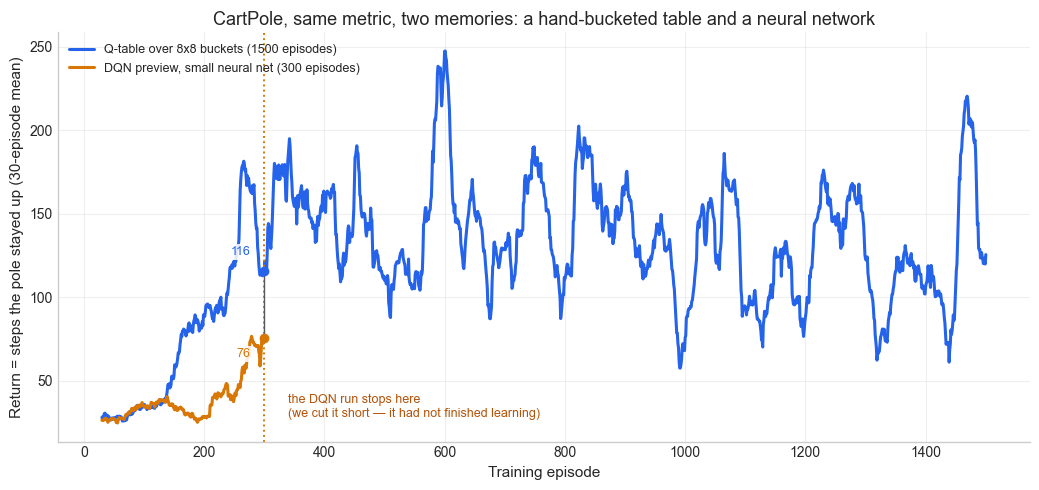

CartPole return (30-episode mean), same metric for both runs
  after 300 episodes  | Q-table:  115.5 | DQN preview:   75.8
  at the end of its run   | Q-table:  125.6 after 1500 episodes | DQN preview:   75.8 after 300 episodes
  the table's 8x8 buckets ignore cart position and cart velocity entirely: 64 states for a 4-number observation


In [9]:
# The comparison this notebook has been building towards: the SAME task (CartPole), the SAME
# metric (how many steps the pole stayed up), two different ways of storing what was learned.
# Nothing here is normalised, rescaled, or hidden — including the part that is unflattering.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Both runs are noisy episode by episode, so smooth both with the SAME window.
# Using different windows would make one curve look steadier than the other for no real reason.
SMOOTHING = 30

# Helper: the running mean of the last SMOOTHING episodes.
def rolling_mean(series, window):
    # np.convolve with a flat kernel is just "average of the last `window` values".
    return np.convolve(np.asarray(series, dtype=float), np.ones(window) / window, mode="valid")

# Part 3's run: a Q-table over 8x8 hand-chosen buckets of pole angle and angular velocity.
table_curve = rolling_mean(cartpole_returns, SMOOTHING)
# Part 4's run: a small neural network trained with DQN, stopped early on purpose.
dqn_curve = rolling_mean(rewards_ep, SMOOTHING)
# The x positions line up with the LAST episode in each averaging window.
table_x = np.arange(SMOOTHING, len(cartpole_returns) + 1)
dqn_x = np.arange(SMOOTHING, len(rewards_ep) + 1)

# One panel, two curves, one shared y axis — that is what makes them comparable.
fig, ax = plt.subplots(figsize=(10.5, 5))
# The bucketed table, over its full 1500 episodes.
ax.plot(table_x, table_curve, color="#2563eb", lw=2.2,
        label=f"Q-table over 8x8 buckets ({len(cartpole_returns)} episodes)")
# The neural network, over the 300 episodes we could afford here.
ax.plot(dqn_x, dqn_curve, color="#d97706", lw=2.2,
        label=f"DQN preview, small neural net ({len(rewards_ep)} episodes)")

# Mark where the DQN run was stopped, so nobody reads its flat end as "it plateaued".
ax.axvline(len(rewards_ep), color="#d97706", ls=":", lw=1.4)
# Put the note in the empty bottom strip of the panel, clear of both curves and the legend.
ax.text(len(rewards_ep) + 40, max(table_curve.max(), dqn_curve.max()) * 0.14,
        "the DQN run stops here\n(we cut it short — it had not finished learning)",
        fontsize=9, color="#b45309", va="center", ha="left")

# Compare the two at the same training budget: what had each achieved by episode 300?
same_budget = len(rewards_ep)
table_at_budget = float(table_curve[same_budget - SMOOTHING])
dqn_at_budget = float(dqn_curve[-1])
# Draw that comparison on the figure rather than leaving it to the reader's memory.
ax.plot([same_budget, same_budget], [dqn_at_budget, table_at_budget], color="0.35", lw=1)
ax.plot(same_budget, table_at_budget, "o", color="#2563eb")
ax.plot(same_budget, dqn_at_budget, "o", color="#d97706")
# Write both numbers next to their dots, so the like-for-like comparison needs no counting.
label_box = dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5)
ax.annotate(f"{table_at_budget:.0f}", (same_budget, table_at_budget), textcoords="offset points",
            xytext=(-10, 12), ha="right", fontsize=9, color="#2563eb", bbox=label_box)
ax.annotate(f"{dqn_at_budget:.0f}", (same_budget, dqn_at_budget), textcoords="offset points",
            xytext=(-10, -14), ha="right", fontsize=9, color="#d97706", bbox=label_box)

# Axis names in words: no "index", no variable names.
ax.set_xlabel("Training episode")
ax.set_ylabel(f"Return = steps the pole stayed up ({SMOOTHING}-episode mean)")
# A title that states what the figure actually shows, including the honest caveat.
ax.set_title("CartPole, same metric, two memories: a hand-bucketed table and a neural network")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The same comparison as numbers, so the picture can be checked rather than trusted.
print(f"CartPole return ({SMOOTHING}-episode mean), same metric for both runs")
print(f"  after {same_budget} episodes  | Q-table: {table_at_budget:6.1f} | DQN preview: {dqn_at_budget:6.1f}")
print(f"  at the end of its run   | Q-table: {table_curve[-1]:6.1f} after {len(cartpole_returns)} episodes"
      f" | DQN preview: {dqn_curve[-1]:6.1f} after {len(rewards_ep)} episodes")
print(f"  the table's 8x8 buckets ignore cart position and cart velocity entirely: "
      f"{N_ANGLE_BINS * N_ANGVEL_BINS} states for a 4-number observation")


### 👁️ Read the figure

**What you are looking at.** Both of this notebook's CartPole runs on one pair of axes: Part 3's Q-table over 8x8 hand-chosen buckets, and Part 4's DQN preview. Same environment, same reward, the same 30-episode smoothing applied to both — the only real difference is how the agent stores what it has learned. Both runs are seeded, so these are the numbers you will get when you run the notebook yourself.

**What to see, including the awkward part.** For the first 130 episodes or so the two curves are on top of each other. Then the table pulls away, and at the fair comparison point — the grey line at episode 300, where both have had exactly the same number of episodes — the table is at **116** steps and the DQN at **76**. Left to run out to 1500 episodes the table wanders noisily between about 60 and 250. **On this graph, the table wins,** and we are not going to hide that: the DQN was deliberately cut off at 300 episodes (the dotted line is our cut-off, not a plateau — its curve is still climbing when it stops), and 300 episodes is nowhere near enough for a network that starts from random weights.

**So why does the course move to DQN at all?** Look at what the table needed from *us*. A human chose which two of CartPole's four numbers to keep and threw away cart position and cart velocity entirely; a human chose where the bin edges go; a human chose 8x8. That is 64 buckets standing in for a continuous four-dimensional space, and it works only because CartPole is small enough for a person to guess well. None of that survives contact with an Atari screen or a robot arm. The network needs no buckets at all: it reads the four raw numbers as they come.

**What it proves:** "tabular versus neural" is not decided by which curve sits higher on a small problem after an unequal number of episodes. It is decided by whether a human can hand-design the state space at all — which is exactly the wall this notebook's story runs into, and where Unit 3 picks up.

## ⚠️ Where this breaks

**The assumption that has to hold:** you can either enumerate the states, or you can afford enough
interactions to fit a function over them. Most real projects fail one of those two.

- **Discretisation loses what it drops, silently.** Our CartPole bucketing threw away cart position
  and velocity, and the agent cannot ever recover them — no amount of training tells it about a
  variable it is not shown. Coarse bins make a compact table that solves a *different, smaller*
  problem than the one you were given.
- **Sample cost is the real barrier, not accuracy.** This is the biggest single difference between
  RL and the supervised learning of Courses 04 and 08. A classifier learns from a dataset that
  already exists. An RL agent has to *generate* its data by acting, and it needs orders of magnitude
  more of it — 38 days of play per Atari game. If every interaction with your system costs money,
  wears out hardware, or affects a customer, that number is the project.
- **Sparse, long-horizon rewards defeat the plain method.** DQN scored 0 on Montezuma's Revenge, for
  the same structural reason your FrozenLake agent needs many episodes before its first success: with
  no reward until a long correct sequence completes, there is nothing to learn from. Unit 5's lesson
  on hierarchy and options is the response to exactly this.
- **Cheaper alternative:** if the state space is genuinely small and you have the transition model,
  do not learn at all — plan, with the value iteration of lesson 03. If you have logs of a system
  already being operated well by people, imitation learning from those logs is far cheaper than
  discovering the same behaviour by trial and error.


## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

Two things are worth carrying out of Unit 1. First, value-based learning did not lose. Analysing RL for
language-model planning, Wang *et al.* (2025) find that policy-gradient training "suffers from diversity
collapse, where output diversity decreases during training and persists even after perfect accuracy is
attained", while Q-learning keeps two advantages — off-policy learning and diversity preservation at
convergence — provided the reward is designed carefully enough to avoid Q-value bias. The update you
implemented above is that method, and its properties are still being argued about in the current
literature rather than filed away. Second, the way a mini-project is *reported* has moved: Rabanser
*et al.* (2026) argue that reliability, not peak capability, is now the binding constraint, and that a
rising benchmark score "ignores whether agents behave consistently across runs". Your FrozenLake 0.95 and
your CartPole 30.3 → 137.8 are each one run with one seed — and lesson 04's "Where this breaks" already
showed you what seeds alone can do to a learning curve. For the rest of this course, a result means
several seeds and a spread; build that habit here, where a rerun costs seconds.

**Read:** Wang *et al.* (2025), <https://arxiv.org/abs/2509.22613> · Rabanser *et al.* (2026),
<https://arxiv.org/abs/2602.16666> (references 5-6 above).


## Closing Takeaway

**Teaching takeaway:** Mini-projects help students connect theory to practice by showing how environment choice, algorithm choice, and debugging fit together.

**If students remember one idea:** A project is not only about getting a score. It is about explaining why a method fits a task and how to evaluate it.

**Quick check before moving on:**
- Can you explain why one project may suit tabular methods while another may need deep RL?
- Can you describe what you would monitor while testing a simple RL mini-project?

**Bridge to the next step:** This closes Unit 1 and prepares students for classical prediction and control algorithms in Unit 2.

**For weaker coders:** The big fork is **small table of states** (Q-learning) vs **huge sensor vectors** (DQN). If you can explain that sentence, Unit 1 clicked.


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
